# Assignment 2 : Data preprocessing
Netflix Dataset

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

# Load Dataset
df = pd.read_csv(r"C:\Users\iikon\Downloads\archive 2\netflix_titles.csv")

### TASK 1:
Identify Data Quality Issues

In [6]:
print("\nDataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Dataset Shape:
(8807, 12)

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate Rows:
0


The dataset contains missing values in several columns such as director, cast, country, date_added, duration and rating. Duplicate rows were also checked.

### TASK 2:
Handle Missing Values

In [10]:
for col in ['director', 'cast', 'country', 'rating','duration','date_added']:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


Mode imputation was used to handle missing values because most affected features are categorical. This method preserves the dataset size and replaces missing values with the most frequent category.

### TASK 3:
Detect and Handle Outliers Using IQR

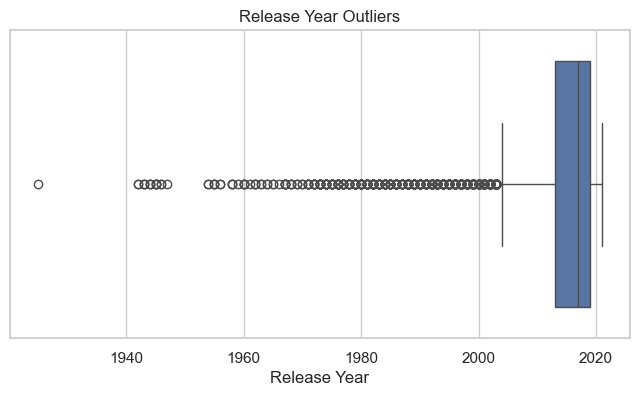

Number of Outliers: 719
Outliers handled successfully.


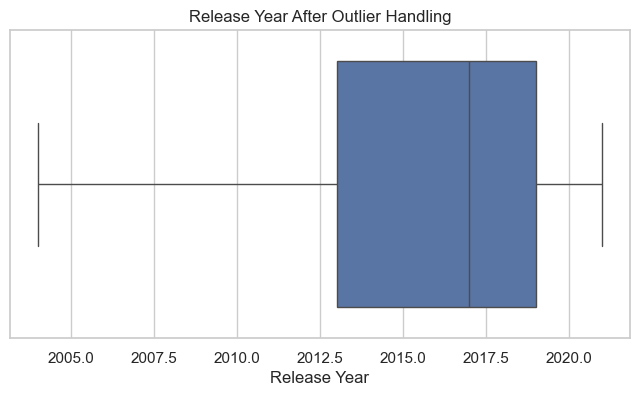

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['release_year'])
plt.title('Release Year Outliers')
plt.xlabel('Release Year')
plt.show()

Q1 = df['release_year'].quantile(0.25)
Q3 = df['release_year'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['release_year'] < lower_bound) |
    (df['release_year'] > upper_bound)
]

print("Number of Outliers:", len(outliers))

df['release_year'] = df['release_year'].clip(
    lower=lower_bound,
    upper=upper_bound
)

print("Outliers handled successfully.")

plt.figure(figsize=(8,4))
sns.boxplot(x=df['release_year'])

plt.title('Release Year After Outlier Handling')
plt.xlabel('Release Year')

plt.show()

The IQR method was used to detect outliers in the release_year column. Extreme values were capped within acceptable bounds.

A boxplot was used to visualize outliers in the release_year feature. The IQR method identified extreme values, which were then handled using capping.


### TASK 4:
Normalize Numerical Features


Min-Max Normalization:
   release_year  release_year_minmax
0          2020             0.941176
1          2021             1.000000
2          2021             1.000000
3          2021             1.000000
4          2021             1.000000

Z-Score Standardization:
   release_year  release_year_zscore
0          2020             0.949065
1          2021             1.151032
2          2021             1.151032
3          2021             1.151032
4          2021             1.151032


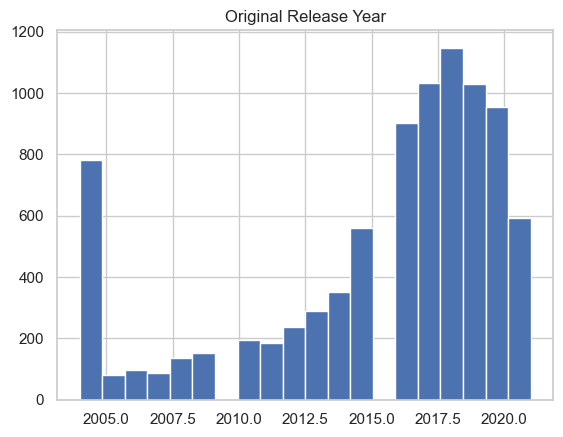

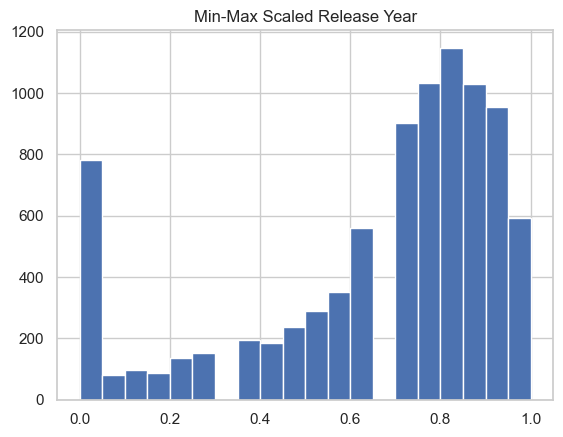

In [19]:
# Min-Max Scaling
minmax_scaler = MinMaxScaler()

df['release_year_minmax'] = minmax_scaler.fit_transform(
    df[['release_year']]
)

print("\nMin-Max Normalization:")
print(df[['release_year', 'release_year_minmax']].head())

# Z-Score Standardization
standard_scaler = StandardScaler()

df['release_year_zscore'] = standard_scaler.fit_transform(
    df[['release_year']]
)

print("\nZ-Score Standardization:")
print(df[['release_year', 'release_year_zscore']].head())

plt.hist(df['release_year'], bins=20)
plt.title('Original Release Year')
plt.show()

plt.hist(df['release_year_minmax'], bins=20)
plt.title('Min-Max Scaled Release Year')
plt.show()



Min-Max scaling transformed values to the range [0,1], while Z-Score standardization centered the data around the mean.

### TASK 5:
PCA and Explained Variance


Explained Variance Ratio:
[1.]

Principal Components Sample:
[[0.94906505]
 [1.15103233]
 [1.15103233]
 [1.15103233]
 [1.15103233]]


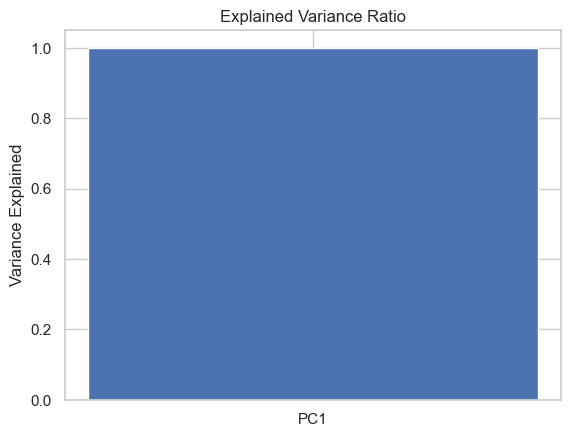

In [18]:
features = df[['release_year']]

scaled_data = StandardScaler().fit_transform(features)

pca = PCA(n_components=1)

principal_components = pca.fit_transform(scaled_data)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nPrincipal Components Sample:")
print(principal_components[:5])

plt.bar(
    ['PC1'],
    pca.explained_variance_ratio_
)

plt.title('Explained Variance Ratio')
plt.ylabel('Variance Explained')
plt.show()



PCA was applied after standardization. The explained variance ratio shows the amount of information retained by the principal component.
Since only one numerical feature was available, the first principal component retained nearly 100% of the variance in the dataset.